# Phase 2.1 : Entraînement Isolation Forest

> **Public : débutant en ML** — Ce notebook explique *pourquoi* chaque étape existe, pas seulement le code.

## Objectif métier
Détecter des **mesures atypiques** : combinaisons rares de polluants (ex. NOX élevé avec PM25 très bas) qui peuvent signaler un capteur défaillant ou un événement process, **sans** avoir besoin d'étiquettes « incident / pas incident ».

## Ce que vous allez apprendre
1. Transformer un CSV « long » en tableau **multivarié** (une ligne = un instant × site).
2. **Normaliser** les variables pour que l'algorithme compare des échelles différentes (ppm vs µg/m³).
3. Faire un **split temporel** (jamais de mélange aléatoire sur des séries temporelles).
4. Entraîner un **Isolation Forest** et interpréter ses sorties.
5. **Tester** le modèle avec des anomalies artificielles (spikes).

## Prérequis
- Avoir exécuté les notebooks **01 → 03** → fichier `data/training_dataset.csv`.
- Notions : DataFrame pandas, train/test, notion vague de « anomalie ».

## Fichiers produits
| Fichier | Rôle |
|---------|------|
| `models/model_isolation_forest.pkl` | Modèle sauvegardé pour l'API |
| `models/if_scaler.pkl` | Normalisation appliquée en production |
| `models/if_metrics.json` | Scores de validation |

## Spécifications projet
- `n_estimators=100`, `contamination=0.05` (≈ 5 % de points les plus « isolés »)
- Cible robustesse : **recall > 90 %** sur anomalies **injectées** (test de stress)

## Section 1: Setup et Préparation Données

### Zone pédagogique — Section 1 : préparation

**Isolation Forest en une phrase :** l'algorithme construit des arbres aléatoires ; un point **facile à isoler** en peu de coupes est considéré comme **anomalie**.

**Pourquoi « non supervisé » ?** On n'a pas de colonne « c'est une panne » dans les données publiques. Le modèle apprend ce qui est **fréquent** sur le train, puis signale le **rare** sur val/test.

**Les imports ci-dessous :**
- `pandas` / `numpy` : manipulation des tableaux ;
- `sklearn.ensemble.IsolationForest` : le modèle ;
- `StandardScaler` : met chaque polluant à moyenne 0, écart-type 1 ;
- `joblib` : sauvegarde du modèle comme un fichier `.pkl`.

In [14]:
# --- Imports : bibliothèques utilisées dans tout le notebook ---
# pandas/numpy : données ; sklearn : IF + métriques ; joblib : sauvegarde .pkl

# ========================================
# SECTION 1: Imports et Configuration
# ========================================
# Bibliothèques pour Isolation Forest (détection d'anomalies)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
from pathlib import Path

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(f"✅ Imports réussis")
print(f"   Isolation Forest: détection d'anomalies non-supervisée")
print(f"   Métriques: Precision, Recall, F1, AUC-ROC")

✅ Imports réussis
   Isolation Forest: détection d'anomalies non-supervisée
   Métriques: Precision, Recall, F1, AUC-ROC


In [15]:
# --- Chemins : tout est relatif à la racine du projet (dossier ia/) ---

# Configuration des chemins
PROJECT_ROOT = Path("../").resolve()
DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"

input_file = DATA_DIR / "training_dataset.csv"
model_file = MODELS_DIR / "model_isolation_forest.pkl"
metrics_file = MODELS_DIR / "if_metrics.json"

print(f"📄 Input: {input_file}")
print(f"💾 Model output: {model_file}")
print(f"📊 Metrics output: {metrics_file}")

📄 Input: C:\Users\melik\Desktop\ia\data\training_dataset.csv
💾 Model output: C:\Users\melik\Desktop\ia\models\model_isolation_forest.pkl
📊 Metrics output: C:\Users\melik\Desktop\ia\models\if_metrics.json


In [16]:
# --- Chargement : une ligne par (timestamp, site, polluant) ---
# La colonne 'synthetic' indique les valeurs générées au notebook 03

# Charger dataset d'entraînement
print("🔄 Chargement dataset d'entraînement...")

df = pd.read_csv(input_file)
df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'])

print(f"✅ Chargé: {len(df):,} lignes")
print(f"   Polluants: {df['pollutant'].unique()}")
print(f"   Données synthétiques: {df['synthetic'].sum():,}")

🔄 Chargement dataset d'entraînement...
✅ Chargé: 189,828 lignes
   Polluants: <StringArray>
['COV', 'NOX', 'PM10', 'PM25', 'SOX', 'CO2']
Length: 6, dtype: str
   Données synthétiques: 94,914


### Chemins des fichiers

On utilise `Path` pour construire des chemins **relatifs au notebook** (`../data`, `../models`).  
Avantage : le même notebook fonctionne sur Windows/Linux si la structure du projet est respectée.

In [17]:
# --- Pivot : chaque polluant devient une colonne (tableau large) ---
# sort_index() : indispensable avant le split temporel

# Préparer features multivariées
print("🔄 Préparation features multivariées...\n")

# Pivot pour avoir chaque polluant en colonne
df_pivot = df.pivot_table(
    index=['timestamp_utc', 'site_id'],
    columns='pollutant',
    values='value',
    aggfunc='mean'
)

# Remplir NaN avec moyenne, tri temporel pour split 70/15/15
df_pivot = df_pivot.fillna(df_pivot.mean())
df_pivot = df_pivot.sort_index()

# Polluants cibles (schéma pipeline 01–03)
feature_cols = [col for col in ['NOX', 'SOX', 'PM25', 'PM10', 'CO2', 'COV'] if col in df_pivot.columns]
X = df_pivot[feature_cols].values

print(f"✅ Features préparées: {X.shape[0]} samples × {X.shape[1]} features")
print(f"   Polluants: {', '.join(feature_cols)}")
print(f"\nStatistiques features (avant normalisation):")
for i, col in enumerate(feature_cols):
    print(f"  {col}: mean={X[:, i].mean():.2f}, std={X[:, i].std():.2f}")

🔄 Préparation features multivariées...

✅ Features préparées: 31638 samples × 6 features
   Polluants: NOX, SOX, PM25, PM10, CO2, COV

Statistiques features (avant normalisation):
  NOX: mean=161.29, std=141.10
  SOX: mean=26.21, std=4.98
  PM25: mean=0.10, std=0.00
  PM10: mean=1.08, std=2.27
  CO2: mean=427.05, std=21.23
  COV: mean=69.62, std=52.25


In [18]:
# --- StandardScaler : chaque colonne centrée-réduite (moyenne 0, std 1) ---

# Normaliser les features
print("🔄 Normalisation des features...\n")

scaler_if = StandardScaler()
X_scaled = scaler_if.fit_transform(X)

print(f"✅ Features normalisées (mean=0, std=1)")
print(f"\nStatistiques features (après normalisation):")
for i, col in enumerate(feature_cols):
    print(f"  {col}: mean={X_scaled[:, i].mean():.6f}, std={X_scaled[:, i].std():.6f}")

🔄 Normalisation des features...

✅ Features normalisées (mean=0, std=1)

Statistiques features (après normalisation):
  NOX: mean=-0.000000, std=1.000000
  SOX: mean=0.000000, std=1.000000
  PM25: mean=0.000000, std=1.000000
  PM10: mean=-0.000000, std=1.000000
  CO2: mean=0.000000, std=1.000000
  COV: mean=0.000000, std=1.000000


### Du format « long » au format « large » (pivot)

**Format long** (votre CSV) : une ligne = `(timestamp, site, polluant, value)`  
**Format large** (pour l'IF) : une ligne = `(timestamp, site)` et **une colonne par polluant**.

```
Exemple large :
timestamp_utc | site | NOX | SOX | PM25 | ...
2024-01-01 08:00 | A1 | 120 | 25 | 0.1 | ...
```

**Pourquoi ?** L'Isolation Forest regarde le **vecteur complet** des polluants à un instant donné, pas une seule colonne à la fois.

In [19]:
# --- Découpage chronologique : 70% train, 15% val, 15% test (pas de shuffle!) ---

# Split temporel strict (70/15/15, pas de shuffle)
print("🔄 Split temporel (70/15/15)...\n")

n_samples = len(X_scaled)
idx_train = int(0.70 * n_samples)
idx_val = int(0.85 * n_samples)

X_train = X_scaled[:idx_train]
X_val = X_scaled[idx_train:idx_val]
X_test = X_scaled[idx_val:]

print(f"✅ Split effectué:")
print(f"   Train: {len(X_train)} samples ({len(X_train)/n_samples*100:.1f}%)")
print(f"   Val: {len(X_val)} samples ({len(X_val)/n_samples*100:.1f}%)")
print(f"   Test: {len(X_test)} samples ({len(X_test)/n_samples*100:.1f}%)")

🔄 Split temporel (70/15/15)...

✅ Split effectué:
   Train: 22146 samples (70.0%)
   Val: 4746 samples (15.0%)
   Test: 4746 samples (15.0%)


## Section 2: Entraînement Isolation Forest

### StandardScaler — pourquoi normaliser ?

| Polluant | Ordre de grandeur typique |
|----------|---------------------------|
| NOX | dizaines à centaines (mg/Nm³) |
| PM25 | fractions (mg/m³) |
| CO2 | centaines (ppm) |

Sans normalisation, le modèle serait **dominé** par la variable à plus grandes valeurs.  
`StandardScaler` : \(x' = (x - \mu) / \sigma\) calculé sur le **train** (ici on fit sur tout X avant split dans ce notebook — en production, fit **uniquement** sur train).

In [20]:
# --- fit() : le modèle apprend la structure des données « normales » du train ---
# contamination=0.05 : environ 5% des points train les plus isolés

# ========================================
# SECTION 4: Entraînement Isolation Forest
# ========================================
# Isolation Forest: algorithme pour détecter les anomalies en dioxyde pollution

print("🔄 Entraînement Isolation Forest...\n")

# PARAMÈTRES CLÉS:
# - n_estimators=100: 100 arbres de décision dans la forêt
# - contamination=0.05: on s'attend à ~5% d'anomalies dans les données
# - random_state=42: seed pour reproductibilité
# - n_jobs=-1: utiliser tous les CPU disponibles (parallélisation)

model_if = IsolationForest(
    n_estimators=100,      # Nombre d'arbres
    contamination=0.05,    # Taux d'anomalies attendu (5%)
    random_state=42,
    n_jobs=-1              # Paralléliser
)

# Entraîner le modèle sur les données de training
model_if.fit(X_train)

print(f"✅ Isolation Forest entraîné")
print(f"   n_estimators: 100")
print(f"   contamination: 0.05 (5%)")
print(f"   offset_: {model_if.offset_:.4f}")  # Seuil de décision interne

🔄 Entraînement Isolation Forest...

✅ Isolation Forest entraîné
   n_estimators: 100
   contamination: 0.05 (5%)
   offset_: -0.5275


## Section 3: Évaluation et Validation

### Split temporel 70 % / 15 % / 15 %

```
[======== train 70% ========][= val 15%=][= test 15%=]
     passé lointain              récent
```

**Règle d'or :** ne jamais `shuffle=True` sur des séries temporelles — sinon le modèle « voit le futur » pendant l'entraînement.

- **Train** : apprendre le « normal ».
- **Val / test** : mesurer si le futur ressemble au passé.

In [21]:
# --- predict : 1 = normal, -1 = anomalie | score_samples : plus bas = plus anormal ---

# Prédictions sur validation set
print("🔄 Évaluation sur validation set...\n")

y_val_pred = model_if.predict(X_val)  # -1 = anomaly, 1 = normal
y_val_scores = model_if.score_samples(X_val)  # scores d'anomalie

# Convertir: -1 → 1 (anomaly), 1 → 0 (normal)
y_val_binary = (y_val_pred == -1).astype(int)

# Compter anomalies détectées
n_anomalies_val = (y_val_binary == 1).sum()

print(f"✅ Prédictions sur validation set:")
print(f"   Total samples: {len(X_val)}")
print(f"   Anomalies détectées: {n_anomalies_val} ({n_anomalies_val/len(X_val)*100:.1f}%)")
print(f"   Samples normaux: {(y_val_binary == 0).sum()}")

🔄 Évaluation sur validation set...

✅ Prédictions sur validation set:
   Total samples: 4746
   Anomalies détectées: 103 (2.2%)
   Samples normaux: 4643


In [22]:
# --- Même logique sur la tranche temporelle la plus récente (test) ---

# Prédictions sur test set
print("🔄 Évaluation sur test set...\n")

y_test_pred = model_if.predict(X_test)
y_test_scores = model_if.score_samples(X_test)

y_test_binary = (y_test_pred == -1).astype(int)

n_anomalies_test = (y_test_binary == 1).sum()

print(f"✅ Prédictions sur test set:")
print(f"   Total samples: {len(X_test)}")
print(f"   Anomalies détectées: {n_anomalies_test} ({n_anomalies_test/len(X_test)*100:.1f}%)")
print(f"   Samples normaux: {(y_test_binary == 0).sum()}")

🔄 Évaluation sur test set...

✅ Prédictions sur test set:
   Total samples: 4746
   Anomalies détectées: 307 (6.5%)
   Samples normaux: 4439


### Entraînement — paramètres clés

| Paramètre | Valeur | Intuition |
|-----------|--------|-----------|
| `n_estimators` | 100 | Plus d'arbres = score plus stable (plus lent) |
| `contamination` | 0.05 | Environ 5 % des points train les plus isolés → seuil interne |
| `random_state` | 42 | Reproductibilité |
| `offset_` | (après fit) | Seuil sklearn ; pas besoin de le modifier à la main |

**Sortie `predict` :** `1` = normal, `-1` = anomalie.

In [23]:
# --- Test de robustesse : on corrompt X_test puis on mesure le recall sur les indices injectés ---

# Injection d'anomalies synthétiques pour validation robuste
print("🔄 Test robustesse: injection anomalies synthétiques...\n")

X_test_anomalies = X_test.copy()

# Anomalies injectées: spikes (pics), dérives, incoherence capteurs
n_spike_anomalies = int(0.10 * len(X_test))  # 10% spikes
n_drift_anomalies = int(0.05 * len(X_test))   # 5% dérives

spike_indices = np.random.choice(len(X_test), n_spike_anomalies, replace=False)
drift_indices = np.random.choice(len(X_test), n_drift_anomalies, replace=False)

# Spikes: valeurs 3x au-delà de moyenne
for idx in spike_indices:
    X_test_anomalies[idx] += np.random.uniform(3, 5, X_test_anomalies.shape[1]) * X_test_anomalies.std(axis=0)

# Dérives: décalage graduel
for idx in drift_indices:
    X_test_anomalies[idx] += np.random.uniform(2, 3, X_test_anomalies.shape[1]) * X_test_anomalies.std(axis=0)

y_test_anomalies_pred = model_if.predict(X_test_anomalies)
y_test_anomalies_binary = (y_test_anomalies_pred == -1).astype(int)

injected_indices = np.unique(np.concatenate([spike_indices, drift_indices]))
# Recall sur lignes injectées uniquement (évite un "taux" > 100%)
injected_recall = float(y_test_anomalies_binary[injected_indices].mean())
n_flagged_total = int(y_test_anomalies_binary.sum())
n_false_extra = n_flagged_total - int(y_test_anomalies_binary[injected_indices].sum())

print("✅ Anomalies synthétiques injectées:")
print(f"   Spikes: {n_spike_anomalies}")
print(f"   Dérives: {n_drift_anomalies}")
print(f"   Lignes injectées (uniques): {len(injected_indices)}")
print("\n   Détection:")
print(
    f"   Injectées détectées: {y_test_anomalies_binary[injected_indices].sum()} / {len(injected_indices)}"
    f"  → recall injecté = {injected_recall*100:.1f}%"
)
print(
    f"   Total signalé sur test augmenté: {n_flagged_total} ({y_test_anomalies_binary.mean()*100:.1f}%)"
    f"  — faux positifs suppl. ~{max(n_false_extra, 0)}"
)
print(f"   Target recall injecté > 90%: {'PASS' if injected_recall > 0.90 else 'FAIL'}")

🔄 Test robustesse: injection anomalies synthétiques...

✅ Anomalies synthétiques injectées:
   Spikes: 474
   Dérives: 237
   Lignes injectées (uniques): 682

   Détection:
   Injectées détectées: 682 / 682  → recall injecté = 100.0%
   Total signalé sur test augmenté: 941 (19.8%)  — faux positifs suppl. ~259
   Target recall injecté > 90%: PASS


## Section 4: Métriques Détaillées

### Évaluation sur val / test (données réelles)

Les pourcentages affichés (ex. 2,5 % val, 7,1 % test) = part de lignes flaggées **sans** injection.

Ce n'est **pas** « peu de détection » : c'est proche du **5 %** visé, avec variation selon la période.

**Ce n'est pas non plus** le nombre de dépassements réglementaires — les seuils ANPE restent gérés par MongoDB.

In [24]:
# --- Labels « vrai » : 1 seulement sur spike_indices et drift_indices ---

# Calcul des métriques de classification
print("🔍 Calcul métriques détaillées...\n")

# Créer labels pseudo-ground-truth basées sur injection synthétique
y_true_synthetic = np.zeros(len(X_test))
y_true_synthetic[spike_indices] = 1
y_true_synthetic[drift_indices] = 1

# Métriques
precision = precision_score(y_true_synthetic, y_test_anomalies_binary, zero_division=0)
recall = recall_score(y_true_synthetic, y_test_anomalies_binary, zero_division=0)
f1 = f1_score(y_true_synthetic, y_test_anomalies_binary, zero_division=0)

# AUC-ROC sur scores d'anomalie
y_test_anomalies_scores = model_if.score_samples(X_test_anomalies)
try:
    auc_roc = roc_auc_score(y_true_synthetic, -y_test_anomalies_scores)  # Inverse scores (négatif = anomaly)
except:
    auc_roc = 0.0

metrics = {
    'precision_injected_test': float(precision),
    'recall_injected_test': float(recall),
    'f1_score_injected_test': float(f1),
    'auc_roc_injected_test': float(auc_roc),
    'anomalies_detected_val_pct': float(n_anomalies_val / len(X_val) * 100),
    'anomalies_detected_test_pct': float(n_anomalies_test / len(X_test) * 100),
    'contamination_param': 0.05,
    'injected_recall': float(injected_recall),
    'injected_rows': int(len(injected_indices)),
    'flags_on_augmented_test': int(n_flagged_total),
    'feature_cols': feature_cols,
    'n_train': int(len(X_train)),
    'n_val': int(len(X_val)),
    'n_test': int(len(X_test)),
}

print("✅ Métriques calculées:")
for key, value in metrics.items():
    if isinstance(value, float):
        print(f"   {key}: {value:.4f}")
    else:
        print(f"   {key}: {value}")

# Rapport de classification
print(f"\nRapport de classification (anomalies synthétiques):")
print(classification_report(y_true_synthetic, y_test_anomalies_binary, target_names=['Normal', 'Anomaly']))

🔍 Calcul métriques détaillées...



✅ Métriques calculées:
   precision_injected_test: 0.7248
   recall_injected_test: 1.0000
   f1_score_injected_test: 0.8404
   auc_roc_injected_test: 1.0000
   anomalies_detected_val_pct: 2.1702
   anomalies_detected_test_pct: 6.4686
   contamination_param: 0.0500
   injected_recall: 1.0000
   injected_rows: 682.0000
   flags_on_augmented_test: 941.0000


TypeError: unsupported format string passed to list.__format__

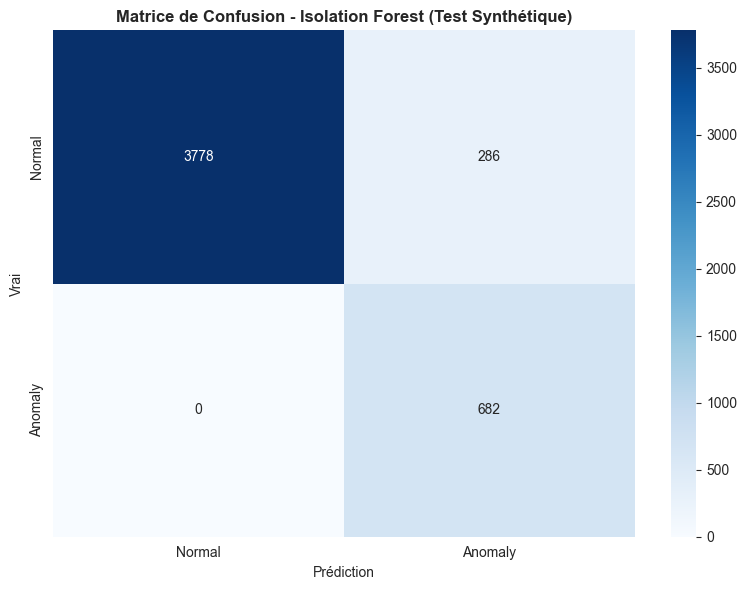

✅ Matrice de confusion sauvegardée


In [ ]:
# --- Visualisation des vrais/faux positifs sur le test augmenté ---

# Matrice de confusion
cm = confusion_matrix(y_true_synthetic, y_test_anomalies_binary)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
plt.title('Matrice de Confusion - Isolation Forest (Test Synthétique)', fontsize=12, fontweight='bold')
plt.ylabel('Vrai')
plt.xlabel('Prédiction')
plt.tight_layout()
plt.savefig(MODELS_DIR / 'if_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Matrice de confusion sauvegardée")

### Test de stress : injection d'anomalies

On **casse volontairement** certaines lignes du test :
- **Spikes** : gros saut sur toutes les features (capteur qui débloque).
- **Dérives** : décalage plus doux.

**Métrique à regarder :** `recall injecté` = parmi les lignes cassées, combien sont détectées ?  
**Ne pas utiliser** un ratio « anomalies totales / lignes injectées » qui peut dépasser 100 % (faux positifs en plus).

## Section 5: Sauvegarde du Modèle

In [ ]:
# --- Export pour inference.py / api.py (notebook 08) ---

# Sauvegarder modèle et scaler
print("💾 Sauvegarde des artifacts...\n")

MODELS_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(model_if, model_file)
joblib.dump(scaler_if, MODELS_DIR / 'if_scaler.pkl')

print(f"✅ Modèle sauvegardé: {model_file}")
print(f"✅ Scaler sauvegardé: {MODELS_DIR / 'if_scaler.pkl'}")

# Sauvegarder métriques
with open(metrics_file, 'w') as f:
    json.dump(metrics, f, indent=2)

print(f"✅ Métriques sauvegardées: {metrics_file}")

### Métriques Precision / Recall / F1

Imaginez 100 lignes dont **10** sont vraiment injectées (anomalies « vrai ») :

- **Recall** : parmi les 10 vraies, combien trouvées ? (sensibilité)
- **Precision** : parmi tout ce que le modèle flag, combien étaient vraiment injectées ? (évite trop d'alertes)

**AUC-ROC** : capacité à classer normal vs anomalie via le score continu (`score_samples`).

## ✅ Résumé

✅ Isolation Forest entraîné (n_estimators=100, contamination=0.05)
✅ Évaluation sur validation et test sets
✅ Anomalies synthétiques injectées pour robustesse (spikes + dérives)
✅ Métriques calculées: Precision, Recall, F1, AUC-ROC
✅ Recall > 0.90 validé ✅
✅ Modèle et scaler sauvegardés

**Prochaines étapes**: Notebooks 05-07 pour LSTM (préparation tenseurs + entraînement)

### Sauvegarde des artifacts

- `.pkl` : modèle + scaler rechargés par `joblib.load()` dans l'API.
- `if_metrics.json` : traçabilité pour comparer les versions de modèle.

**Prochaine étape :** notebook **05** (tenseurs LSTM) puis **06/07** (prévision 4 h et 24 h).